In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("dataset/trips_2023.csv", thousands=',')
print(df.shape)

(2622331, 18)


In [3]:
print("Observations: ", len(df))

Observations:  2622331


In [5]:
print(df.head(1))

   Unnamed: 0       Id_recorrido  duracion_recorrido fecha_origen_recorrido  \
0           1  17910696BAEcobici                1848    2023-04-24 10:30:10   

  id_estacion_origen nombre_estacion_origen direccion_estacion_origen  \
0       358BAEcobici           249 - Balbín               2519 Conesa   

   long_estacion_origen  lat_estacion_origen fecha_destino_recorrido  \
0            -58.465586           -34.561486     2023-04-24 11:00:58   

  id_estacion_destino nombre_estacion_destino direccion_estacion_destino  \
0        278BAEcobici            233 - MONROE                2519 Superi   

   long_estacion_destino  lat_estacion_destino       id_usuario  \
0             -58.469813            -34.564122  861866BAEcobici   

  modelo_bicicleta género  
0           ICONIC   MALE  


In [6]:
print("df.isnull",df.isnull().sum())
df.isnull().mean() * 100  # percentage missing per column

df.isnull Unnamed: 0                        0
Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido           0
id_estacion_destino               2
nombre_estacion_destino           2
direccion_estacion_destino        2
long_estacion_destino             2
lat_estacion_destino              2
id_usuario                        0
modelo_bicicleta                  0
género                        11966
dtype: int64


Unnamed: 0                    0.000000
Id_recorrido                  0.000000
duracion_recorrido            0.000000
fecha_origen_recorrido        0.000000
id_estacion_origen            0.000000
nombre_estacion_origen        0.000000
direccion_estacion_origen     0.000000
long_estacion_origen          0.000000
lat_estacion_origen           0.000000
fecha_destino_recorrido       0.000000
id_estacion_destino           0.000076
nombre_estacion_destino       0.000076
direccion_estacion_destino    0.000076
long_estacion_destino         0.000076
lat_estacion_destino          0.000076
id_usuario                    0.000000
modelo_bicicleta              0.000000
género                        0.456312
dtype: float64

In [7]:
df.dtypes


Unnamed: 0                      int64
Id_recorrido                      str
duracion_recorrido              int64
fecha_origen_recorrido            str
id_estacion_origen                str
nombre_estacion_origen            str
direccion_estacion_origen         str
long_estacion_origen          float64
lat_estacion_origen           float64
fecha_destino_recorrido           str
id_estacion_destino               str
nombre_estacion_destino           str
direccion_estacion_destino        str
long_estacion_destino         float64
lat_estacion_destino          float64
id_usuario                        str
modelo_bicicleta                  str
género                            str
dtype: object

In [9]:
df.corr(numeric_only=True)

,Unnamed: 0,duracion_recorrido,long_estacion_origen,lat_estacion_origen,long_estacion_destino,lat_estacion_destino
Unnamed: 0,1.000000,0.000257,-0.022838,0.028889,-0.020271,0.028204
duracion_recorrido,0.000257,1.000000,-0.003039,-0.000885,-0.000230,-0.010858
long_estacion_origen,-0.022838,-0.003039,1.000000,-0.288874,0.839675,-0.247372
lat_estacion_origen,0.028889,-0.000885,-0.288874,1.000000,-0.257547,0.764288
long_estacion_destino,-0.020271,-0.000230,0.839675,-0.257547,1.000000,-0.281013
lat_estacion_destino,0.028204,-0.010858,-0.247372,0.764288,-0.281013,1.000000


In [49]:
print("Unique users:", df['id_usuario'].nunique())
print("Unique stations (origin):", df['id_estacion_origen'].nunique())
print("Average duration: ",df['duracion_recorrido'].mean())

Unique users: 212068
Unique stations (origin): 364
Average duration:  1380.6133199813448


In [11]:
avg_rides_per_user = len(df) / df['id_usuario'].nunique()
print("Average rides per user:", avg_rides_per_user)

Average rides per user: 12.365519550332913


In [5]:
def rides_per_user(df):
    return df.groupby('id_usuario').size().sort_values(ascending=False)

rides_per_user = rides_per_user(df)
print(rides_per_user.describe())

count    212068.000000
mean         12.365520
std          32.260147
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max        1122.000000
dtype: float64


Text(0, 0.5, 'cantidad de repeticiones')

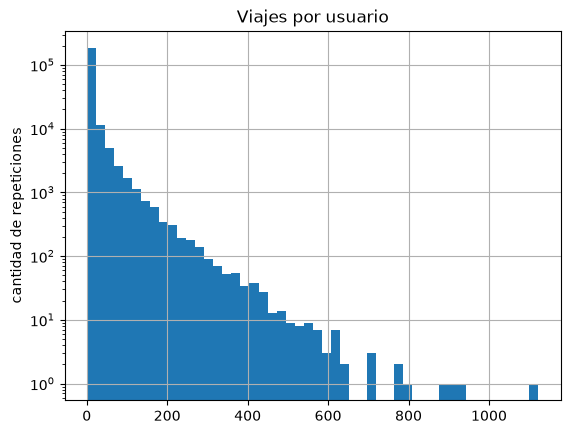

In [29]:
rides_per_user.hist(bins=50, log=True)
plt.title('Viajes por usuario')
plt.ylabel('cantidad de repeticiones')

id_estacion_origen
175BAEcobici    35834
14BAEcobici     31698
8BAEcobici      27249
5BAEcobici      24924
202BAEcobici    22779
130BAEcobici    22213
54BAEcobici     21812
289BAEcobici    21660
128BAEcobici    21034
152BAEcobici    20914
dtype: int64


<Axes: >

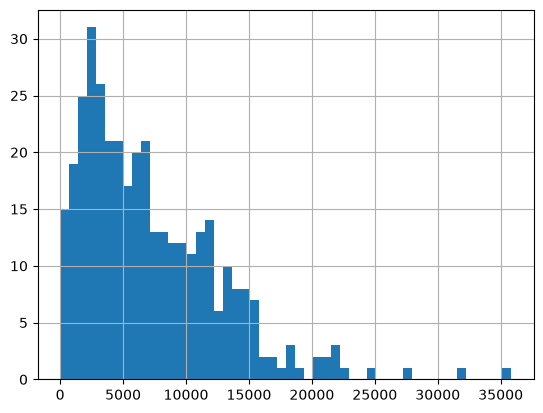

In [47]:
rides_per_station = df.groupby('id_estacion_origen').size().sort_values(ascending=False)
print(rides_per_station[0:10])
rides_per_station.hist(bins=50)

In [49]:
rides_per_station.mean()

np.float64(7204.206043956044)

In [32]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [36]:
rides_pu_q1, rides_pu_q2, rides_pu_q3 = cuartiles(rides_per_user)
print(f"q1: {rides_pu_q1} | q2: {rides_pu_q2} | q3: {rides_pu_q3}")

q1: 1.0 | q2: 3.0 | q3: 8.0


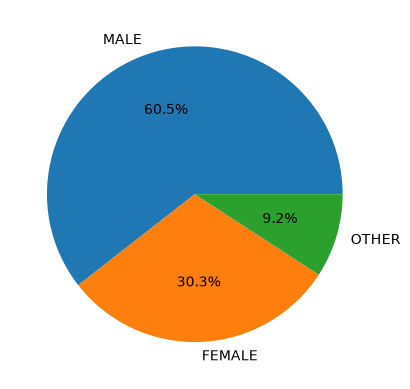

In [51]:
df['género'].value_counts().plot(kind='pie', autopct='%1.1f%%', ylabel='')
# plt.title('Distribución por género')
plt.show()

<Axes: ylabel='duracion_recorrido'>

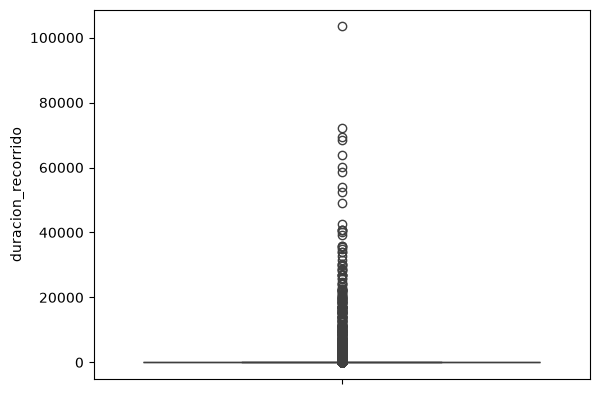

In [63]:

# Convert to minutes and round
duracion_minutos = df['duracion_recorrido_min'] = (df['duracion_recorrido'] / 60).round()

q1 = duracion_minutos.quantile(0.25)
q2 = duracion_minutos.quantile(0.5)
q3 = duracion_minutos.quantile(0.75)

# sns.boxplot(data=titanic_df, y='age', color="lightblue", ax=ax[0])

sns.boxplot(data=duracion_minutos)
